# ⚽ MultiElo Football: Match Monte Carlo & World Cup Group Stage Simulation

This notebook demonstrates how to use the `multielo-football` library to:
1. Load multi-dimensional team ratings ($R^e, R^o, R^d$) and compute Poisson match expectations ($\lambda_A, \lambda_B$).
2. Perform **1,000 Monte Carlo match simulations** between two top national teams and plot a 2D scoreline probability heatmap.
3. Simulate a 4-team **FIFA World Cup Group Stage round-robin** under official FIFA tiebreaker rules (Points $\rightarrow$ Goal Difference $\rightarrow$ Goals For $\rightarrow$ Head-to-Head).
4. Run **1,000 Monte Carlo group stage tournaments** to calculate empirical probabilities for each team finishing in 1st, 2nd, 3rd, and 4th place, visualized as a heatmap.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import multielo library
import multielo
import warnings
warnings.filterwarnings('ignore')

# Set clean seaborn plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 120

print(f"multielo version: {multielo.__file__}")


multielo version: /Users/rennocosta/matchdataset/multielo_package/multielo/__init__.py


## Part 1: Two-Team Match Prediction & 1,000 Monte Carlo Score Heatmap

We evaluate a neutral-venue match between **Spain** and **England** using model specification **$M_{32}$** (3-Elo Complete Bivariate Poisson GLM).


In [2]:
# 1. Define Multi-Dimensional Ratings (Overall Elo, Offensive, Defensive)
spain_ratings = {'elo': 2279.0, 'off': 2276.6, 'def': 2412.4}
england_ratings = {'elo': 2117.7, 'off': 2341.5, 'def': 2226.9}

# 2. Predict match expectations under M32 Poisson GLM model
pred = multielo.predict(spain_ratings, england_ratings, model_specs='M32', is_neutral=True)

print("=== Analytical Model Prediction ===")
print(f"Spain Win Probability   : {pred['p_win_a']*100:.1f}%")
print(f"Draw Probability        : {pred['p_draw']*100:.1f}%")
print(f"England Win Probability : {pred['p_win_b']*100:.1f}%")
print(f"Expected Goals (Spain)  : {pred['expected_goals_a']:.3f}")
print(f"Expected Goals (England): {pred['expected_goals_b']:.3f}")
print(f"Analytical Most Likely Score: {pred['most_likely_score'][0]} - {pred['most_likely_score'][1]}")


=== Analytical Model Prediction ===
Spain Win Probability   : 45.2%
Draw Probability        : 26.6%
England Win Probability : 28.2%
Expected Goals (Spain)  : 1.518
Expected Goals (England): 1.142
Analytical Most Likely Score: 1 - 1


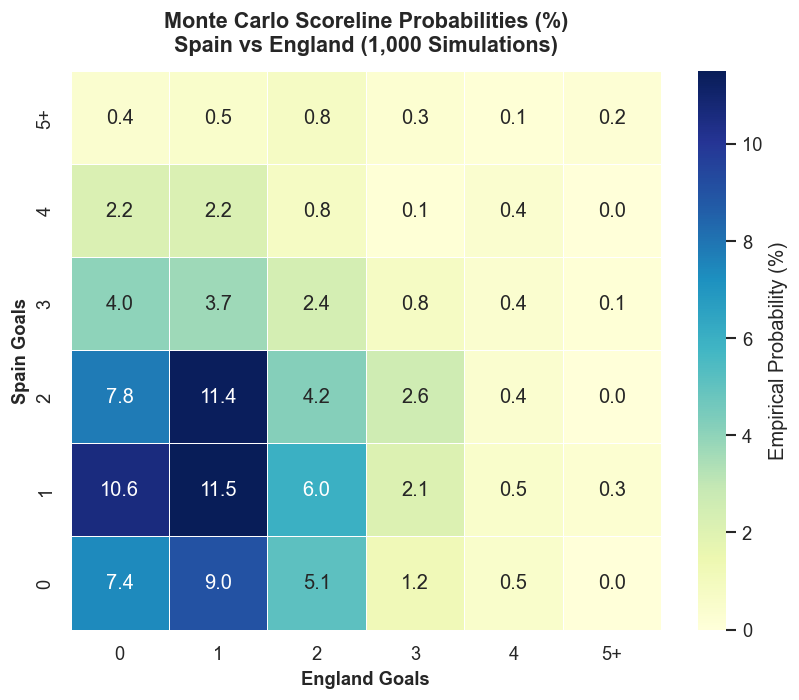

In [3]:
# 3. Perform 1,000 Monte Carlo Match Simulations
N_SIMS = 1000
np.random.seed(42)

lambda_spain = pred['expected_goals_a']
lambda_england = pred['expected_goals_b']

sim_goals_spain = np.random.poisson(lambda_spain, N_SIMS)
sim_goals_england = np.random.poisson(lambda_england, N_SIMS)

# 4. Construct 2D Score Frequency Matrix (0 to 5+ goals)
max_goals = 5
score_matrix = np.zeros((max_goals + 1, max_goals + 1))

for g_s, g_e in zip(sim_goals_spain, sim_goals_england):
    r_s = min(g_s, max_goals)
    r_e = min(g_e, max_goals)
    score_matrix[r_s, r_e] += 1

score_matrix_pct = (score_matrix / N_SIMS) * 100

# 5. Plot Score Probability Heatmap
plt.figure(figsize=(7, 6))
labels = [str(i) for i in range(max_goals)] + [f'{max_goals}+']

ax = sns.heatmap(
    score_matrix_pct,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={'label': 'Empirical Probability (%)'},
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.5
)

plt.title("Monte Carlo Scoreline Probabilities (%)\nSpain vs England (1,000 Simulations)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("England Goals", fontsize=11, fontweight='semibold')
plt.ylabel("Spain Goals", fontsize=11, fontweight='semibold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Part 2: 4-Team FIFA World Cup Group Stage Simulation

We evaluate a 4-team World Cup "Group of Death":
- 🇪🇸 **Spain**
- 🇧🇷 **Brazil**
- 🇩🇪 **Germany**
- 🇯🇵 **Japan**

We implement official **FIFA World Cup Tiebreaker Rules**:
1. Points ($3$ for win, $1$ for draw, $0$ for loss)
2. Goal Difference ($GD = GF - GA$)
3. Goals For ($GF$)
4. Head-to-head match result / Random coin toss


In [4]:
# Define Group Teams and Multi-Dimensional Ratings
group_teams = {
    'Spain': {'elo': 2279.0, 'off': 2276.6, 'def': 2412.4},
    'Brazil': {'elo': 2250.0, 'off': 2310.0, 'def': 2350.0},
    'Germany': {'elo': 2180.0, 'off': 2240.0, 'def': 2260.0},
    'Japan': {'elo': 1980.0, 'off': 2020.0, 'def': 2010.0}
}

def simulate_match(team_a, team_b):
    pred = multielo.predict(group_teams[team_a], group_teams[team_b], model_specs='M32', is_neutral=True)
    g_a = np.random.poisson(pred['expected_goals_a'])
    g_b = np.random.poisson(pred['expected_goals_b'])
    return g_a, g_b

def run_group_stage():
    teams = list(group_teams.keys())
    stats = {t: {'pld': 0, 'w': 0, 'd': 0, 'l': 0, 'gf': 0, 'ga': 0, 'gd': 0, 'pts': 0} for t in teams}
    
    matches = [
        ('Spain', 'Brazil'), ('Germany', 'Japan'),
        ('Spain', 'Germany'), ('Brazil', 'Japan'),
        ('Spain', 'Japan'), ('Brazil', 'Germany')
    ]
    
    match_results = []
    for t_a, t_b in matches:
        g_a, g_b = simulate_match(t_a, t_b)
        match_results.append((t_a, g_a, g_b, t_b))
        
        stats[t_a]['pld'] += 1; stats[t_b]['pld'] += 1
        stats[t_a]['gf'] += g_a; stats[t_a]['ga'] += g_b
        stats[t_b]['gf'] += g_b; stats[t_b]['ga'] += g_a
        stats[t_a]['gd'] += (g_a - g_b); stats[t_b]['gd'] += (g_b - g_a)
        
        if g_a > g_b:
            stats[t_a]['pts'] += 3; stats[t_a]['w'] += 1; stats[t_b]['l'] += 1
        elif g_b > g_a:
            stats[t_b]['pts'] += 3; stats[t_b]['w'] += 1; stats[t_a]['l'] += 1
        else:
            stats[t_a]['pts'] += 1; stats[t_b]['pts'] += 1; stats[t_a]['d'] += 1; stats[t_b]['d'] += 1
            
    # Apply FIFA World Cup Tiebreaker Sorting: Pts -> GD -> GF -> Random Tiebreaker
    sorted_teams = sorted(teams, key=lambda t: (
        stats[t]['pts'],
        stats[t]['gd'],
        stats[t]['gf'],
        np.random.rand()
    ), reverse=True)
    
    return sorted_teams, stats, match_results


In [5]:
# Run a Single Group Stage Simulation
np.random.seed(101)
standings, stats, match_results = run_group_stage()

print("=== Single Tournament Group Stage Match Results ===")
for t_a, g_a, g_b, t_b in match_results:
    print(f"{t_a:10s} {g_a} - {g_b} {t_b}")

print("\n=== Final Group Classification (FIFA WC Tiebreakers) ===")
df_standings = pd.DataFrame([
    {
        'Rank': pos + 1,
        'Team': team,
        'Pld': stats[team]['pld'],
        'W': stats[team]['w'],
        'D': stats[team]['d'],
        'L': stats[team]['l'],
        'GF': stats[team]['gf'],
        'GA': stats[team]['ga'],
        'GD': f"{stats[team]['gd']:+d}",
        'Pts': stats[team]['pts']
    }
    for pos, team in enumerate(standings)
])

df_standings


=== Single Tournament Group Stage Match Results ===
Spain      1 - 0 Brazil
Germany    3 - 2 Japan
Spain      1 - 0 Germany
Brazil     3 - 1 Japan
Spain      3 - 0 Japan
Brazil     0 - 2 Germany

=== Final Group Classification (FIFA WC Tiebreakers) ===


,Rank,Team,Pld,W,D,L,GF,GA,GD,Pts
0,1,Spain,3,3,0,0,5,0,+5,9
1,2,Germany,3,2,0,1,5,3,+2,6
2,3,Brazil,3,1,0,2,3,4,-1,3
3,4,Japan,3,0,0,3,3,9,-6,0


### 1,000 Monte Carlo Group Stage Tournaments & Finishing Position Heatmap

Now we simulate the group stage **1,000 times** to compute the empirical probability distribution of each team finishing in **1st, 2nd, 3rd, and 4th place**.


In [6]:
# Run 1,000 Full Group Stage Tournament Simulations
N_GROUPS = 1000
np.random.seed(42)

rank_counts = {t: [0, 0, 0, 0] for t in group_teams.keys()}

for _ in range(N_GROUPS):
    st, _, _ = run_group_stage()
    for pos, team in enumerate(st):
        rank_counts[team][pos] += 1

# Calculate percentages (%)
df_rank_pct = pd.DataFrame(
    rank_counts,
    index=['1st Place (Winner)', '2nd Place (Runner-up)', '3rd Place', '4th Place']
).T

df_rank_pct = (df_rank_pct / N_GROUPS) * 100

print("=== Empirical Finishing Position Probabilities (%) ===")
display(df_rank_pct.round(1))


=== Empirical Finishing Position Probabilities (%) ===


,1st Place (Winner),2nd Place (Runner-up),3rd Place,4th Place
Spain,41.4,31.7,23.4,3.5
Brazil,39.2,34.0,22.2,4.6
Germany,18.5,31.3,41.8,8.4
Japan,0.9,3.0,12.6,83.5


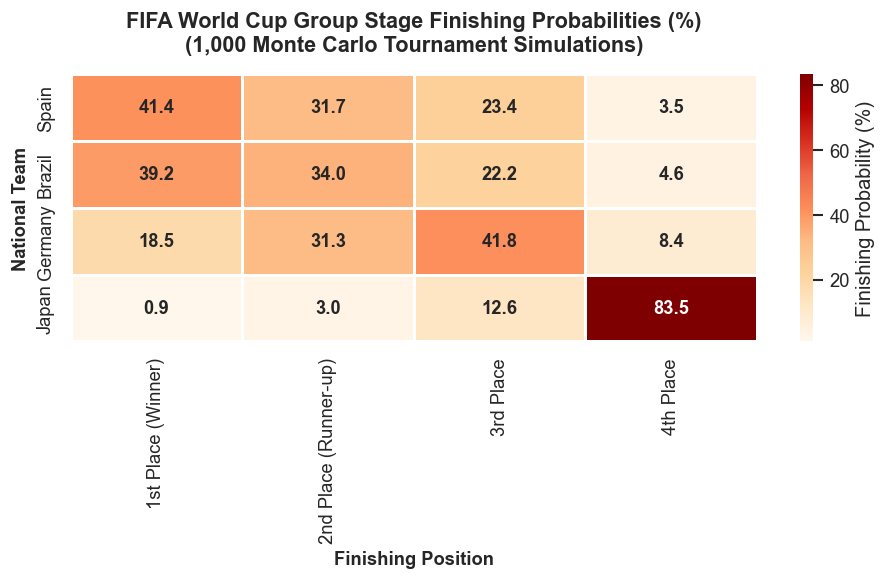

In [7]:
# Plot Group Stage Finishing Probabilities Heatmap
plt.figure(figsize=(8, 5))

ax = sns.heatmap(
    df_rank_pct,
    annot=True,
    fmt=".1f",
    cmap="OrRd",
    cbar_kws={'label': 'Finishing Probability (%)'},
    linewidths=0.8,
    annot_kws={"size": 11, "weight": "bold"}
)

plt.title("FIFA World Cup Group Stage Finishing Probabilities (%)\n(1,000 Monte Carlo Tournament Simulations)", fontsize=13, fontweight='bold', pad=14)
plt.xlabel("Finishing Position", fontsize=11, fontweight='semibold')
plt.ylabel("National Team", fontsize=11, fontweight='semibold')
plt.tight_layout()
plt.show()
